<a href="https://colab.research.google.com/github/amorelo/analiticadedatos3/blob/main/C%C3%93DIGO_SEGUNDA_ENTREGA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Clasificación con Redes Neuronales (RNA)

Este notebook implementa un flujo de trabajo completo para un problema de clasificación binaria utilizando Redes Neuronales Multicapa (MLPClassifier) de `scikit-learn`. El proceso incluye carga y limpieza de datos, análisis exploratorio de datos (EDA), preprocesamiento de características, entrenamiento de modelos, ajuste de hiperparámetros, selección de características, evaluación de modelos y generación de informes.

El objetivo es predecir la variable objetivo `M3_30AC`.

### 1. Configuración Inicial e Importaciones

Se importan las librerías necesarias y se definen las constantes globales para el archivo de datos, el directorio de salida, la variable objetivo y la semilla para la reproducibilidad.

In [ ]:
import os
import warnings
from dataclasses import dataclass

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib import rcParams
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")


#  SISTEMA DE DISEÑO
PALETTE_PRIMARY   = ["#FF4500", "#6A1B9A"]      # naranja vivo + morado
PALETTE_EXTENDED  = ["#FF4500", "#6A1B9A", "#2E7D32", "#E65100", "#6A1B9A"]
PALETTE_SEQ_BLUE  = "Blues"
PALETTE_SEQ_RED   = "YlOrRd"

ACADEMIC_COLORS = {
    "bg"          : "#FAFAFA",
    "panel"       : "#FFFFFF",
    "grid"        : "#E0E0E0",
    "text_main"   : "#1A1A2E",
    "text_sub"    : "#555566",
    "accent"      : "#1B3A6B",
    "accent2"     : "#C0392B",
    "spine"       : "#CCCCCC",
}

def set_academic_style():
    """Aplica el estilo académico global a todas las figuras de Matplotlib."""
    rcParams.update({
        # Fuentes
        "font.family"        : "serif",
        "font.serif"         : ["Georgia", "Times New Roman", "DejaVu Serif"],
        "font.size"          : 11,
        "axes.titlesize"     : 13,
        "axes.labelsize"     : 11,
        "xtick.labelsize"    : 10,
        "ytick.labelsize"    : 10,
        "legend.fontsize"    : 10,
        "legend.title_fontsize": 10,
        # Figura
        "figure.facecolor"   : ACADEMIC_COLORS["bg"],
        "axes.facecolor"     : ACADEMIC_COLORS["panel"],
        "axes.edgecolor"     : ACADEMIC_COLORS["spine"],
        "axes.linewidth"     : 0.8,
        # Grid
        "axes.grid"          : True,
        "grid.color"         : ACADEMIC_COLORS["grid"],
        "grid.linewidth"     : 0.6,
        "grid.linestyle"     : "--",
        # Ticks
        "xtick.direction"    : "out",
        "ytick.direction"    : "out",
        "xtick.major.size"   : 4,
        "ytick.major.size"   : 4,
        "xtick.color"        : ACADEMIC_COLORS["text_sub"],
        "ytick.color"        : ACADEMIC_COLORS["text_sub"],
        # Leyenda
        "legend.frameon"     : True,
        "legend.framealpha"  : 0.92,
        "legend.edgecolor"   : ACADEMIC_COLORS["spine"],
        # Guardado
        "savefig.dpi"        : 200,
        "savefig.bbox"       : "tight",
    })

def style_axes(ax, title, xlabel, ylabel, subtitle=None):
    """Aplica estilos estándar a un eje: título, etiquetas, spines y grid."""
    ax.set_title(title, fontsize=13, fontweight="bold",
                 color=ACADEMIC_COLORS["text_main"], pad=14, loc="left")
    if subtitle:
        ax.annotate(subtitle, xy=(0, 1.01), xycoords="axes fraction",
                    fontsize=9, color=ACADEMIC_COLORS["text_sub"], style="italic")
    ax.set_xlabel(xlabel, fontsize=11, color=ACADEMIC_COLORS["text_sub"], labelpad=8)
    ax.set_ylabel(ylabel, fontsize=11, color=ACADEMIC_COLORS["text_sub"], labelpad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(ACADEMIC_COLORS["spine"])
    ax.spines["bottom"].set_color(ACADEMIC_COLORS["spine"])
    ax.tick_params(colors=ACADEMIC_COLORS["text_sub"])
    ax.yaxis.set_tick_params(labelcolor=ACADEMIC_COLORS["text_sub"])
    ax.xaxis.set_tick_params(labelcolor=ACADEMIC_COLORS["text_sub"])

def add_figure_label(fig, label):
    """Añade una etiqueta de figura tipo 'Figura N.' en la parte inferior."""
    fig.text(0.5, -0.02, label, ha="center", fontsize=9,
             color=ACADEMIC_COLORS["text_sub"], style="italic")

# Activar estilos globales al importar
set_academic_style()


#  CONSTANTES
CSV_PATH     = "BD taller clasificación.csv"
OUTPUT_DIR   = "outputs_rna"
TARGET       = "M3_30AC"
RANDOM_STATE = 42

In [ ]:
# Configuración de estilo profesional
def set_professional_style():
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({
        'figure.dpi': 120,
        'axes.titlesize': 14,
        'axes.titleweight': 'bold',
        'axes.labelsize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 10,
        'font.family': 'sans-serif'
    })
    return sns.color_palette("Spectral", as_cmap=False) # Paleta consistente

PALETTE = set_professional_style()

### 2. Definición de Clases y Funciones de Utilidad

Aquí se definen las clases y funciones auxiliares que se utilizarán a lo largo del notebook para la manipulación de datos, preprocesamiento, modelado y evaluación.

In [ ]:
@dataclass
class EvalResult:
    """Clase para almacenar los resultados de evaluación de un modelo."""
    nombre: str
    umbral: float
    accuracy: float
    precision: float
    recall: float
    auc_roc: float

def ensure_output_dirs(base_dir: str) -> None:
    """Asegura que los directorios de salida existan."""
    # Esta función ya no creará un subdirectorio 'figuras' ya que las figuras se mostrarán inline.
    os.makedirs(base_dir, exist_ok=True)

In [ ]:
def parse_locale_number(value):
    """Parsea un número con formato local (punto como miles, coma como decimal) a float."""
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text == "":
        return np.nan

    # Elimina separador de miles y transforma coma decimal a punto.
    text = text.replace(".", "").replace(",", ".")
    try:
        return float(text)
    except ValueError:
        return np.nan

def load_and_clean_data(path: str) -> pd.DataFrame:
    """Carga y limpia los datos del archivo CSV."""
    df = pd.read_csv(path, sep=";", dtype=str)

    expected_columns = [
        "Caso",
        "Perfil",
        "Estado",
        "Edad",
        "Genero",
        "ScoreCrediticio",
        "PorcentajeFinanciacion",
        "Plazo",
        "IngresoEstimado",
        "Gastos",
        "CapacidadDePago",
        "ValorCuotaMensual",
        TARGET,
    ]

    missing_cols = [c for c in expected_columns if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Faltan columnas esperadas: {missing_cols}")

    numeric_cols = [
        "Edad",
        "ScoreCrediticio",
        "PorcentajeFinanciacion",
        "Plazo",
        "IngresoEstimado",
        "Gastos",
        "CapacidadDePago",
        "ValorCuotaMensual",
        TARGET,
    ]

    for col in numeric_cols:
        df[col] = df[col].apply(parse_locale_number)

    df[TARGET] = df[TARGET].fillna(0).astype(int)
    df["Caso"] = pd.to_numeric(df["Caso"], errors="coerce")

    # Limpieza basica de texto para categoricas.
    for col in ["Perfil", "Estado", "Genero"]:
        df[col] = df[col].fillna("DESCONOCIDO").astype(str).str.strip().str.upper()

    return df

def class_distribution(df: pd.DataFrame, target: str) -> pd.Series:
    """Calcula la distribución de clases de la variable objetivo."""
    return df[target].value_counts(normalize=True).sort_index()

In [ ]:
import os
import warnings
from dataclasses import dataclass

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib import rcParams
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")


#  SISTEMA DE DISEÑO
PALETTE_PRIMARY   = ["#FF4500", "#6A1B9A"]      # naranja vivo + morado
PALETTE_EXTENDED  = ["#FF4500", "#6A1B9A", "#2E7D32", "#E65100", "#6A1B9A"]
PALETTE_SEQ_BLUE  = "Blues"
PALETTE_SEQ_RED   = "YlOrRd"

ACADEMIC_COLORS = {
    "bg"          : "#FAFAFA",
    "panel"       : "#FFFFFF",
    "grid"        : "#E0E0E0",
    "text_main"   : "#1A1A2E",
    "text_sub"    : "#555566",
    "accent"      : "#1B3A6B",
    "accent2"     : "#C0392B",
    "spine"       : "#CCCCCC",
}

def set_academic_style():
    """Aplica el estilo académico global a todas las figuras de Matplotlib."""
    rcParams.update({
        # Fuentes
        "font.family"        : "serif",
        "font.serif"         : ["Georgia", "Times New Roman", "DejaVu Serif"],
        "font.size"          : 11,
        "axes.titlesize"     : 13,
        "axes.labelsize"     : 11,
        "xtick.labelsize"    : 10,
        "ytick.labelsize"    : 10,
        "legend.fontsize"    : 10,
        "legend.title_fontsize": 10,
        # Figura
        "figure.facecolor"   : ACADEMIC_COLORS["bg"],
        "axes.facecolor"     : ACADEMIC_COLORS["panel"],
        "axes.edgecolor"     : ACADEMIC_COLORS["spine"],
        "axes.linewidth"     : 0.8,
        # Grid
        "axes.grid"          : True,
        "grid.color"         : ACADEMIC_COLORS["grid"],
        "grid.linewidth"     : 0.6,
        "grid.linestyle"     : "--",
        # Ticks
        "xtick.direction"    : "out",
        "ytick.direction"    : "out",
        "xtick.major.size"   : 4,
        "ytick.major.size"   : 4,
        "xtick.color"        : ACADEMIC_COLORS["text_sub"],
        "ytick.color"        : ACADEMIC_COLORS["text_sub"],
        # Leyenda
        "legend.frameon"     : True,
        "legend.framealpha"  : 0.92,
        "legend.edgecolor"   : ACADEMIC_COLORS["spine"],
        # Guardado
        "savefig.dpi"        : 200,
        "savefig.bbox"       : "tight",
    })

def style_axes(ax, title, xlabel, ylabel, subtitle=None):
    """Aplica estilos estándar a un eje: título, etiquetas, spines y grid."""
    ax.set_title(title, fontsize=13, fontweight="bold",
                 color=ACADEMIC_COLORS["text_main"], pad=14, loc="left")
    if subtitle:
        ax.annotate(subtitle, xy=(0, 1.01), xycoords="axes fraction",
                    fontsize=9, color=ACADEMIC_COLORS["text_sub"], style="italic")
    ax.set_xlabel(xlabel, fontsize=11, color=ACADEMIC_COLORS["text_sub"], labelpad=8)
    ax.set_ylabel(ylabel, fontsize=11, color=ACADEMIC_COLORS["text_sub"], labelpad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(ACADEMIC_COLORS["spine"])
    ax.spines["bottom"].set_color(ACADEMIC_COLORS["spine"])
    ax.tick_params(colors=ACADEMIC_COLORS["text_sub"])
    ax.yaxis.set_tick_params(labelcolor=ACADEMIC_COLORS["text_sub"])
    ax.xaxis.set_tick_params(labelcolor=ACADEMIC_COLORS["text_sub"])

def add_figure_label(fig, label):
    """Añade una etiqueta de figura tipo 'Figura N.' en la parte inferior."""
    fig.text(0.5, -0.02, label, ha="center", fontsize=9,
             color=ACADEMIC_COLORS["text_sub"], style="italic")

# Activar estilos globales al importar
set_academic_style()


#  CONSTANTES
CSV_PATH     = "BD taller clasificación.csv"
OUTPUT_DIR   = "outputs_rna"
TARGET       = "M3_30AC"
RANDOM_STATE = 42

#  EDA  – GRÁFICAS
def plot_eda(df: pd.DataFrame, target: str) -> None:
    """Genera gráficos de EDA con estilo académico profesional."""
    print("Generando gráficos EDA (estilo académico)…")

    # 1. DISTRIBUCIÓN DE CLASES
    fig, ax = plt.subplots(figsize=(7, 5))
    class_pct = df[target].value_counts(normalize=True).sort_index() * 100
    labels = [f"Clase {int(c)}" for c in class_pct.index]
    colors = [PALETTE_PRIMARY[0], PALETTE_PRIMARY[1]]

    bars = ax.bar(labels, class_pct.values, color=colors,
                  width=0.5, edgecolor="white", linewidth=1.2, zorder=3)

    # Etiquetas de valor sobre cada barra
    for bar, val in zip(bars, class_pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.6,
                f"{val:.2f}%",
                ha="center", va="bottom",
                fontsize=11, fontweight="bold",
                color=ACADEMIC_COLORS["text_main"])

    # Línea de referencia al 50 %
    ax.axhline(50, color=ACADEMIC_COLORS["text_sub"],
               linestyle=":", linewidth=1, label="50 %", zorder=2)

    style_axes(ax,
               title="Distribución de Clases",
               xlabel="Clase objetivo (M3_30AC)",
               ylabel="Proporción (%)",
               subtitle=f"N = {len(df):,} observaciones")
    ax.set_ylim(0, max(class_pct.values) * 1.20)
    ax.legend(fontsize=9)
    add_figure_label(fig, "Figura 1. Distribución porcentual de la variable objetivo M3_30AC.")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fig1_distribucion_clases.png")) # Save figure
    plt.show()

    # 2. SCORE CREDITICIO POR CLASE
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(
        data=df, x=target, y="ScoreCrediticio",
        palette={str(c): col for c, col in zip(sorted(df[target].unique()), PALETTE_PRIMARY)}, # Fix: convert keys to string
        width=0.45, linewidth=1.2,
        flierprops=dict(marker="o", markerfacecolor="none",
                        markeredgecolor=ACADEMIC_COLORS["text_sub"],
                        markersize=4, alpha=0.5),
        ax=ax
    )
    ax.set_xticklabels([f"Clase {int(c)}" for c in sorted(df[target].unique())])

    # Mediana anotada
    for i, cls in enumerate(sorted(df[target].unique())):
        med = df.loc[df[target] == cls, "ScoreCrediticio"].median()
        ax.annotate(f"Md = {med:.0f}",
                    xy=(i, med), xytext=(i + 0.28, med),
                    fontsize=8.5, color=ACADEMIC_COLORS["text_sub"],
                    va="center",
                    arrowprops=dict(arrowstyle="-", color=ACADEMIC_COLORS["spine"]))

    style_axes(ax,
               title="Score Crediticio por Clase",
               xlabel="Clase objetivo (M3_30AC)",
               ylabel="Score crediticio (puntos)",
               subtitle="Diagrama de caja con valores atípicos")
    add_figure_label(fig, "Figura 2. Distribución del score crediticio según la clase objetivo.")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fig2_score_crediticio.png")) # Save figure
    plt.show()

    # 3. CAPACIDAD DE PAGO POR CLASE
    fig, ax = plt.subplots(figsize=(7, 5))
    p1  = np.nanpercentile(df["CapacidadDePago"].dropna(), 1)
    p99 = np.nanpercentile(df["CapacidadDePago"].dropna(), 99)

    sns.boxplot(
        data=df, x=target, y="CapacidadDePago",
        palette={str(c): col for c, col in zip(sorted(df[target].unique()), PALETTE_PRIMARY)}, # Fix: convert keys to string
        width=0.45, linewidth=1.2,
        flierprops=dict(marker="o", markerfacecolor="none",
                        markeredgecolor=ACADEMIC_COLORS["text_sub"],
                        markersize=4, alpha=0.4),
        ax=ax
    )
    ax.set_ylim(p1, p99)
    ax.set_xticklabels([f"Clase {int(c)}" for c in sorted(df[target].unique())])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    style_axes(ax,
               title="Capacidad de Pago por Clase",
               xlabel="Clase objetivo (M3_30AC)",
               ylabel="Capacidad de pago (COP)",
               subtitle="Rango limitado al percentil 1–99 para excluir valores extremos")
    add_figure_label(fig, "Figura 3. Capacidad de pago según la clase objetivo (sin valores extremos).")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fig3_capacidad_pago.png")) # Save figure
    plt.show()

    # 4. DENSIDAD DE PORCENTAJE DE FINANCIACIÓN
    fig, ax = plt.subplots(figsize=(8, 5))
    unique_classes = sorted(df[target].dropna().unique())
    fill_colors = [PALETTE_PRIMARY[0], PALETTE_PRIMARY[1]]
    fill_alphas  = [0.25, 0.20]

    for cls, fc, fa in zip(unique_classes, fill_colors, fill_alphas):
        subset = df.loc[df[target] == cls, "PorcentajeFinanciacion"].dropna()
        sns.kdeplot(subset, ax=ax, color=fc, linewidth=2,
                    fill=True, alpha=fa, label=f"Clase {int(cls)}")

    style_axes(ax,
               title="Densidad de Porcentaje de Financiación por Clase",
               xlabel="Porcentaje de financiación (%)",
               ylabel="Densidad de probabilidad",
               subtitle="Estimación de densidad kernel (KDE), normalización independiente")
    ax.legend(title="Clase (M3_30AC)", frameon=True)
    add_figure_label(fig, "Figura 4. Distribución del porcentaje de financiación por clase objetivo.")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fig4_densidad_financiacion.png")) # Save figure
    plt.show()

    # 5. SCATTER INGRESO vs CUOTA
    sample_df = df.sample(min(6000, len(df)), random_state=RANDOM_STATE)
    fig, ax = plt.subplots(figsize=(8, 6))

    for cls, color in zip(sorted(sample_df[target].unique()), PALETTE_PRIMARY):
        sub = sample_df[sample_df[target] == cls]
        ax.scatter(
            sub["IngresoEstimado"],
            sub["ValorCuotaMensual"],
            c=color, alpha=0.45, s=18,
            edgecolors="none",
            label=f"Clase {int(cls)}", zorder=3
        )

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

    style_axes(ax,
               title="Ingreso Estimado vs. Valor de Cuota Mensual",
               xlabel="Ingreso estimado (millones COP)",
               ylabel="Valor cuota mensual (millones COP)",
               subtitle=f"Muestra aleatoria de {len(sample_df):,} observaciones")
    ax.legend(title="Clase (M3_30AC)", frameon=True, markerscale=1.5)
    add_figure_label(fig, "Figura 5. Relación entre ingreso estimado y valor de cuota mensual por clase.")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fig5_ingreso_cuota.png")) # Save figure
    plt.show()

    print("Gráficos EDA generados.")

In [ ]:
def get_feature_groups(df: pd.DataFrame, target: str):
    """Divide las columnas del DataFrame en características numéricas y categóricas."""
    drop_cols = ["Caso", target]
    features = [c for c in df.columns if c not in drop_cols]
    categorical = [c for c in features if df[c].dtype == "object"]
    numeric = [c for c in features if c not in categorical]
    return features, numeric, categorical

def build_pipeline(numeric_features: list, categorical_features: list, model: MLPClassifier) -> Pipeline:
    """Construye un pipeline de preprocesamiento y modelo MLPClassifier."""
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num", # Transformador para características numéricas
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")), # Imputación de nulos con la mediana
                    ("scaler", StandardScaler()),                  # Escalado estándar
                ]),
                numeric_features,
            ),
            (
                "cat", # Transformador para características categóricas
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")), # Imputación de nulos con el valor más frecuente
                    ("onehot", OneHotEncoder(handle_unknown="ignore")), # One-Hot Encoding
                ]),
                categorical_features,
            ),
        ],
        remainder="drop", # Descarta las columnas no especificadas
    )

    return Pipeline([("preprocess", preprocessor), ("model", model)])

In [ ]:
def evaluate_at_threshold(y_true: pd.Series, y_prob: np.ndarray, threshold: float, name: str) -> EvalResult:
    """Evalúa el rendimiento del modelo en un umbral de probabilidad dado."""
    y_pred = (y_prob >= threshold).astype(int)
    return EvalResult(
        nombre=name,
        umbral=threshold,
        accuracy=accuracy_score(y_true, y_pred),
        precision=precision_score(y_true, y_pred, zero_division=0),
        recall=recall_score(y_true, y_pred, zero_division=0),
        auc_roc=roc_auc_score(y_true, y_prob),
    )

def tune_mlp(X_train: pd.DataFrame, y_train: pd.Series, num_feats: list, cat_feats: list):
    """Realiza una búsqueda de hiperparámetros para el MLPClassifier usando validación interna."""
    grid = ParameterGrid(
        {
            "hidden_layer_sizes": [(32,), (64,), (64, 32)], # Configuraciones de capas ocultas
            "alpha": [0.0001, 0.001],                     # Parámetro de regularización L2
            "learning_rate_init": [0.001, 0.003],         # Tasa de aprendizaje inicial
        }
    )

    best_auc = -np.inf
    best_cfg = None

    # Dividir el conjunto de entrenamiento para validación interna
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
    )

    print("Iniciando tuning de hiperparámetros...")
    for i, cfg in enumerate(grid):
        print(f"  Probando configuración {i+1}/{len(grid)}: {cfg}")
        model = MLPClassifier(
            random_state=RANDOM_STATE,
            max_iter=220, # Número máximo de iteraciones
            early_stopping=True, # Detener entrenamiento si el score de validación no mejora
            n_iter_no_change=12, # Número de épocas sin mejora para activar early stopping
            **cfg,
        )
        pipe = build_pipeline(num_feats, cat_feats, model)
        pipe.fit(X_tr, y_tr)
        prob = pipe.predict_proba(X_val)[:, 1]
        auc_val = roc_auc_score(y_val, prob)
        if auc_val > best_auc:
            best_auc = auc_val
            best_cfg = cfg
    print(f"Tuning completado. Mejor AUC en validación: {best_auc:.4f}")
    return best_cfg, best_auc

In [ ]:
def top_numeric_features_by_mi(df: pd.DataFrame, target: str, top_k: int = 5) -> list[str]:
    """Selecciona las top K características numéricas con mayor información mutua respecto al target."""
    numeric_candidates = [
        "Edad",
        "ScoreCrediticio",
        "PorcentajeFinanciacion",
        "Plazo",
        "IngresoEstimado",
        "Gastos",
        "CapacidadDePago",
        "ValorCuotaMensual",
    ]
    tmp = df[numeric_candidates + [target]].copy()
    # Imputar medianas para calcular MI, si hay nulos.
    for c in numeric_candidates:
        tmp[c] = tmp[c].fillna(tmp[c].median())

    mi = mutual_info_classif(tmp[numeric_candidates], tmp[target], random_state=RANDOM_STATE)
    ranking = (
        pd.DataFrame({"variable": numeric_candidates, "mi": mi})
        .sort_values("mi", ascending=False)
        .reset_index(drop=True)
    )
    return ranking["variable"].head(top_k).tolist()

In [ ]:
#  CURVAS ROC, PR Y PÉRDIDA

def display_curve_plots(y_true: pd.Series, y_prob: np.ndarray, title_prefix: str):
    """Muestra la Curva ROC y la Curva Precision-Recall con estilo académico."""

    # ── Curva ROC ──────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.fill_between(fpr, tpr, alpha=0.12, color=PALETTE_PRIMARY[0])
    ax.plot(fpr, tpr, color=PALETTE_PRIMARY[0], linewidth=2.2,
            label=f"Modelo  (AUC = {roc_auc:.4f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color=ACADEMIC_COLORS["text_sub"],
            linewidth=1.2, label="Clasificador aleatorio (AUC = 0.50)")

    # Punto de mayor distancia al azar (Youden)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    ax.scatter(fpr[best_idx], tpr[best_idx],
               color=PALETTE_PRIMARY[1], s=80, zorder=5,
               label=f"Punto óptimo  (FPR={fpr[best_idx]:.2f}, TPR={tpr[best_idx]:.2f})")

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    style_axes(ax,
               title=f"Curva ROC — {title_prefix}",
               xlabel="Tasa de Falsos Positivos (1 − Especificidad)",
               ylabel="Tasa de Verdaderos Positivos (Sensibilidad)",
               subtitle="Área bajo la curva ROC como medida de discriminación global")
    ax.legend(loc="lower right", fontsize=9)
    add_figure_label(fig, f"Curva ROC del modelo {title_prefix}.")
    plt.tight_layout()
    plt.show()

    # ── Curva Precision-Recall ─────────────────────────────────────────────
    precision_arr, recall_arr, _ = precision_recall_curve(y_true, y_prob)
    ap = auc(recall_arr, precision_arr)
    baseline = y_true.mean()

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.fill_between(recall_arr, precision_arr, alpha=0.12, color=PALETTE_PRIMARY[1])
    ax.plot(recall_arr, precision_arr, color=PALETTE_PRIMARY[1], linewidth=2.2,
            label=f"Modelo  (AP = {ap:.4f})")
    ax.axhline(baseline, linestyle="--", color=ACADEMIC_COLORS["text_sub"],
               linewidth=1.2, label=f"Referencia proporcional ({baseline:.2f})")

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    style_axes(ax,
               title=f"Curva Precisión-Recall — {title_prefix}",
               xlabel="Recall (Exhaustividad)",
               ylabel="Precisión",
               subtitle="Área bajo la curva PR como medida de rendimiento en clases desbalanceadas")
    ax.legend(loc="upper right", fontsize=9)
    add_figure_label(fig, f"Curva Precisión-Recall del modelo {title_prefix}.")
    plt.tight_layout()
    plt.show()


def display_loss_plot(model: MLPClassifier, title_prefix: str):
    """Muestra la curva de pérdida del entrenamiento con estilo académico."""
    if not (hasattr(model, "loss_curve_") and model.loss_curve_):
        print(f"No hay curva de pérdida disponible para {title_prefix}.")
        return

    loss = model.loss_curve_
    epochs = np.arange(1, len(loss) + 1)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.fill_between(epochs, loss, alpha=0.10, color=PALETTE_PRIMARY[0])
    ax.plot(epochs, loss, color=PALETTE_PRIMARY[0], linewidth=2.2)

    # Mínimo
    min_idx = int(np.argmin(loss))
    ax.scatter(epochs[min_idx], loss[min_idx],
               color=PALETTE_PRIMARY[1], s=80, zorder=5,
               label=f"Pérdida mínima  ({loss[min_idx]:.4f}, época {epochs[min_idx]})")

    style_axes(ax,
               title=f"Curva de Pérdida — {title_prefix}",
               xlabel="Época de entrenamiento",
               ylabel="Pérdida (log-loss)",
               subtitle="Optimización mediante gradiente estocástico (Adam)")
    ax.legend(fontsize=9)
    add_figure_label(fig, f"Evolución de la función de pérdida durante el entrenamiento — {title_prefix}.")
    plt.tight_layout()
    plt.show()


def display_deciles_plot(y_true: pd.Series, y_prob: np.ndarray, title_prefix: str):
    """Muestra la tasa de clase positiva por decil con estilo académico."""
    df_dec = pd.DataFrame({"y": y_true, "p": y_prob})
    df_dec = df_dec.sort_values("p", ascending=False).reset_index(drop=True)
    num_deciles = min(10, len(df_dec))
    if num_deciles == 0:
        print("Datos insuficientes para gráfico de deciles.")
        return

    df_dec["decil"] = pd.qcut(df_dec.index, num_deciles, labels=False, duplicates="drop") + 1
    dec = df_dec.groupby("decil", as_index=False)["y"].mean()
    baseline = y_true.mean()

    # Gradiente de color: mayor tasa → color más intenso, usando la paleta de morados para la clase positiva
    norm_vals = (dec["y"] - dec["y"].min()) / (dec["y"].max() - dec["y"].min() + 1e-9)
    bar_colors = plt.cm.Blues(0.35 + 0.55 * norm_vals)

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(dec["decil"].astype(str), dec["y"],
                  color=bar_colors, edgecolor="white", linewidth=0.8, zorder=3)

    # Etiquetas
    for bar, val in zip(bars, dec["y"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.1%}",
                ha="center", va="bottom", fontsize=8.5,
                color=ACADEMIC_COLORS["text_main"])

    ax.axhline(baseline, color=PALETTE_PRIMARY[1], linestyle="--",
               linewidth=1.4, label=f"Tasa global ({baseline:.1%})", zorder=4)

    style_axes(ax,
               title=f"Tasa de Clase Positiva por Decil — {title_prefix}",
               xlabel="Decil de probabilidad predicha (1 = mayor score)",
               ylabel="Tasa de positivos observados",
               subtitle="Ordenamiento descendente por probabilidad predicha del modelo")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=9)
    add_figure_label(fig, f"Análisis de deciles del modelo {title_prefix}.")
    plt.tight_layout()
    plt.show()

In [ ]:
def threshold_search(y_true: pd.Series, y_prob: np.ndarray, metric: str = "recall"):
    """Realiza una búsqueda de umbrales para optimizar una métrica dada (recall por defecto)."""
    thresholds = np.arange(0.2, 0.81, 0.01) # Rango de umbrales a probar
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        rows.append(
            {
                "threshold": t,
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "accuracy": accuracy_score(y_true, y_pred),
            }
        )
    res = pd.DataFrame(rows)
    # Encontrar el umbral que maximiza la métrica especificada
    idx = res[metric].idxmax()
    return res, float(res.loc[idx, "threshold"])

### 3. Carga y Preparación de Datos

Se carga el archivo CSV y se realiza una limpieza inicial, incluyendo la conversión de tipos de datos y el manejo de valores nulos. También se muestra la distribución de la variable objetivo.

In [ ]:
# Asegurar que el directorio de salida para CSV y TXT exista
ensure_output_dirs(OUTPUT_DIR)

# Cargar y limpiar los datos
print(f"Cargando y limpiando datos desde: {CSV_PATH}")
df = load_and_clean_data(CSV_PATH)
print(f"Datos cargados. {len(df)} registros.")

# Mostrar las primeras filas del DataFrame limpio
print("Primeras 5 filas del DataFrame limpio:")
display(df.head())

# Mostrar la distribución de clases
distribucion_clases = class_distribution(df, TARGET)
print(f"\nDistribución de clases de '{TARGET}':")
display(distribucion_clases)

Cargando y limpiando datos desde: BD taller clasificación.csv
Datos cargados. 21091 registros.
Primeras 5 filas del DataFrame limpio:


,Caso,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,1004991730,ASALARIADO,NUEVO,30.0,FEMENINO,748.0,0.6850,72.0,3289800.0,2430509.0,0.361093,2379693.0,0
1,1005097331,INDEPENDIENTE,NUEVO,46.0,MASCULINO,670.0,0.2783,60.0,2425440.0,1621788.0,0.948770,847046.0,0
2,1005120587,INDEPENDIENTE,USADO,39.0,MASCULINO,752.0,1.0000,60.0,30000000.0,3614019.0,12.009213,2197145.0,0
3,1005152562,ASALARIADO,USADO,38.0,FEMENINO,758.0,1.0000,84.0,1631331.0,1725245.0,-0.068706,1366896.0,0
4,1005153782,INDEPENDIENTE,NUEVO,60.0,FEMENINO,846.0,0.6596,72.0,20907400.0,3439342.0,13.004595,1343222.0,0



Distribución de clases de 'M3_30AC':


,proportion
M3_30AC,
0,0.960315
1,0.039685


### 4. Análisis Exploratorio de Datos (EDA)

Se generan varios gráficos para entender la distribución de las variables y su relación con la variable objetivo. Estos gráficos se mostrarán directamente en el notebook.

Generando gráficos EDA (estilo académico)…


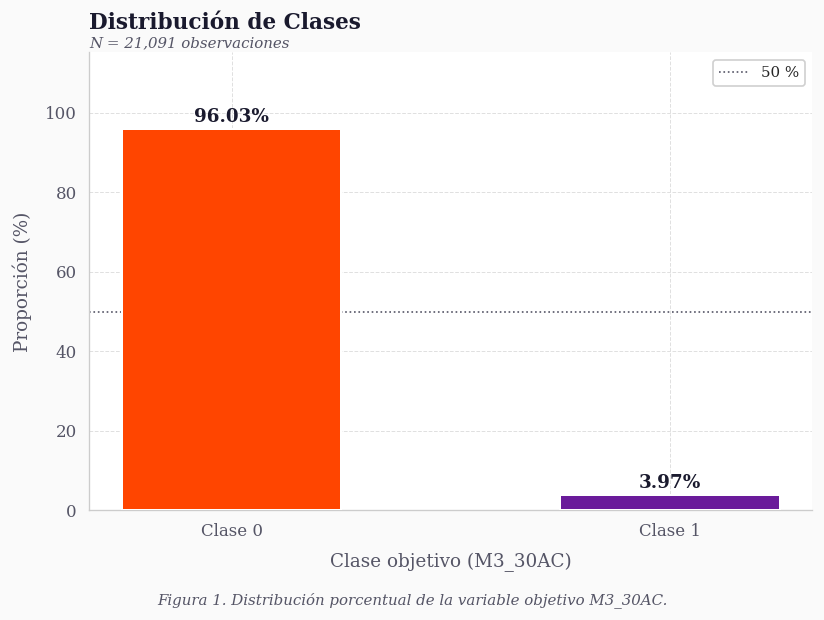

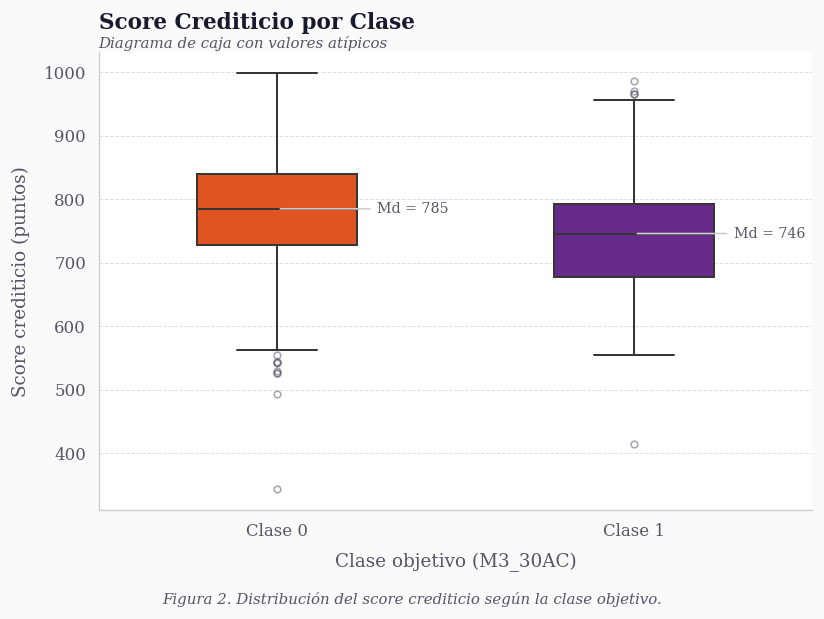

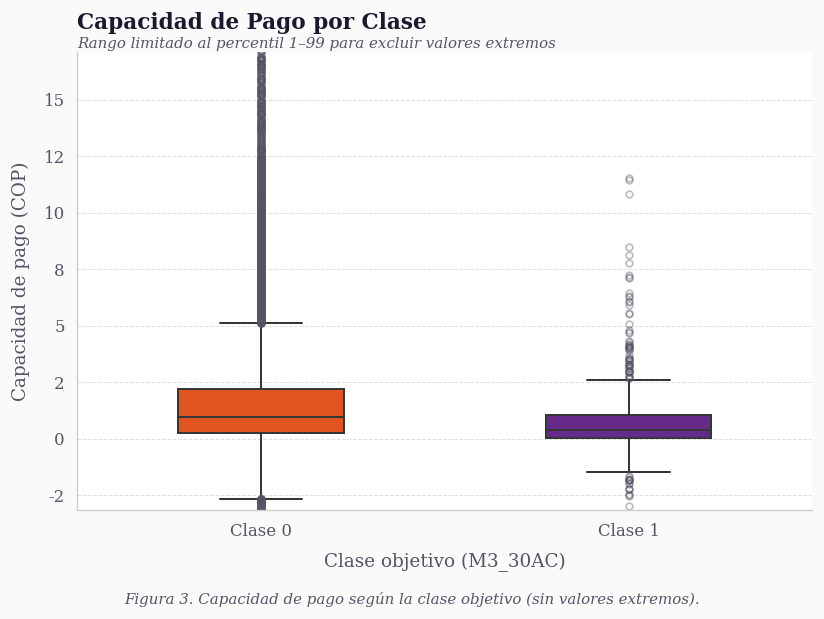

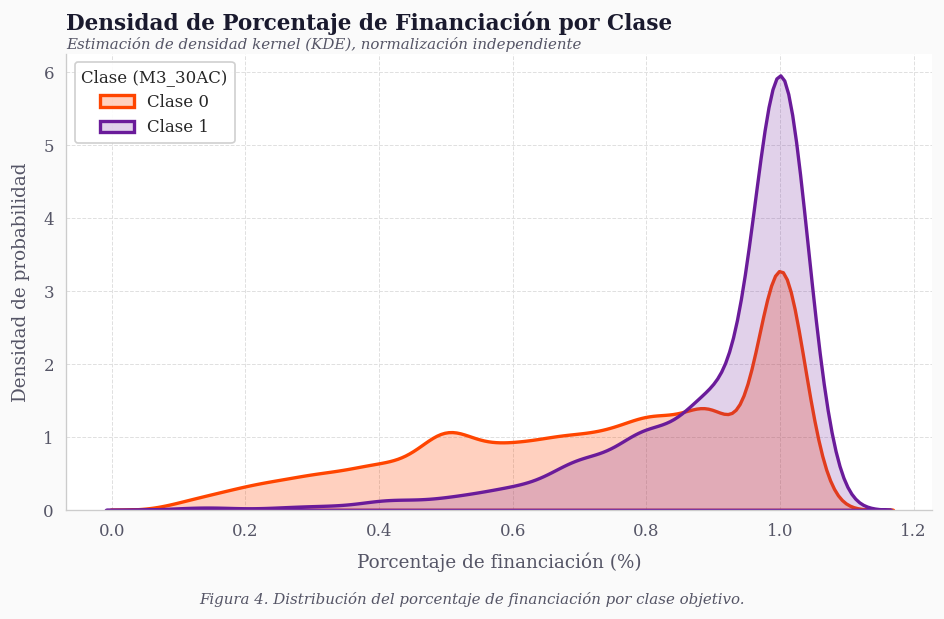

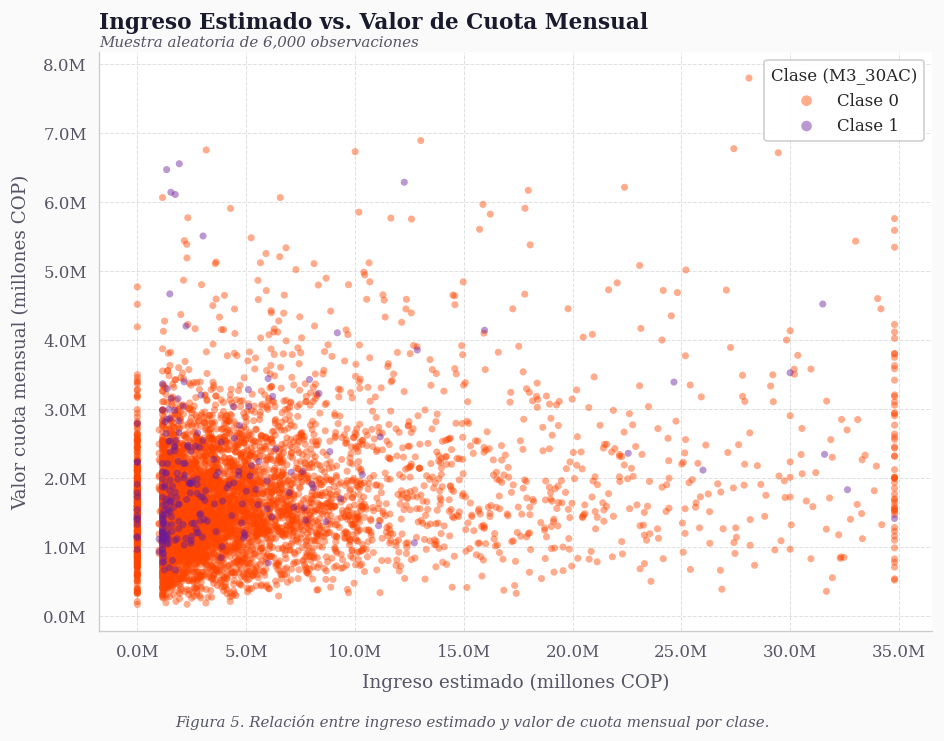

Gráficos EDA generados.


In [ ]:
# Generar y mostrar gráficos EDA
plot_eda(df, TARGET)

### 5. División de Datos y Preparación de Características

Los datos se dividen en conjuntos de entrenamiento y prueba. Se identifican las características numéricas y categóricas para el preprocesamiento.

In [ ]:
# Dividir los datos en características (X) y objetivo (y)
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# Dividir en conjuntos de entrenamiento y prueba (80/20 estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)} registros")
print(f"Tamaño del conjunto de prueba: {len(X_test)} registros")

# Obtener los grupos de características (todas, numéricas, categóricas)
feat_all, num_all, cat_all = get_feature_groups(df, TARGET)
print(f"\nCaracterísticas numéricas identificadas: {num_all}")
print(f"Características categóricas identificadas: {cat_all}")

Tamaño del conjunto de entrenamiento: 16872 registros
Tamaño del conjunto de prueba: 4219 registros

Características numéricas identificadas: ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo', 'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']
Características categóricas identificadas: ['Perfil', 'Estado', 'Genero']


### 6. Modelo Base: Entrenamiento y Evaluación

Se entrena un modelo MLPClassifier con una configuración predeterminada utilizando todas las características disponibles y se evalúa su rendimiento en el conjunto de prueba. Se muestran métricas clave y curvas de rendimiento.


--- Entrenando Modelo Base ---
Modelo Base entrenado.

Evaluación del Modelo Base (umbral=0.5):
EvalResult(nombre='Base_umbral_0.5', umbral=0.5, accuracy=0.9597060914908746, precision=0.0, recall=0.0, auc_roc=np.float64(0.748834020015251))


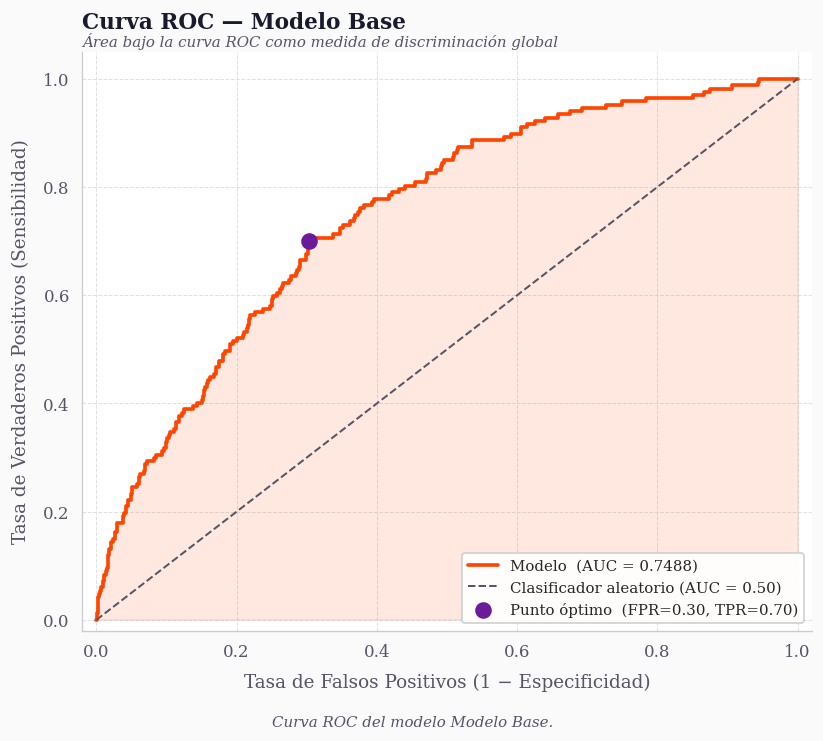

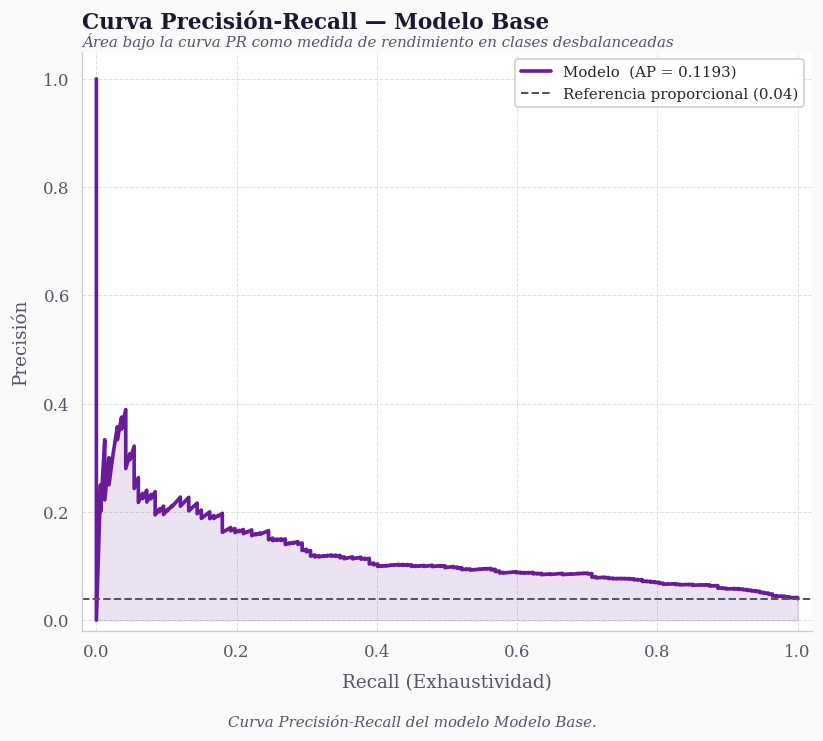

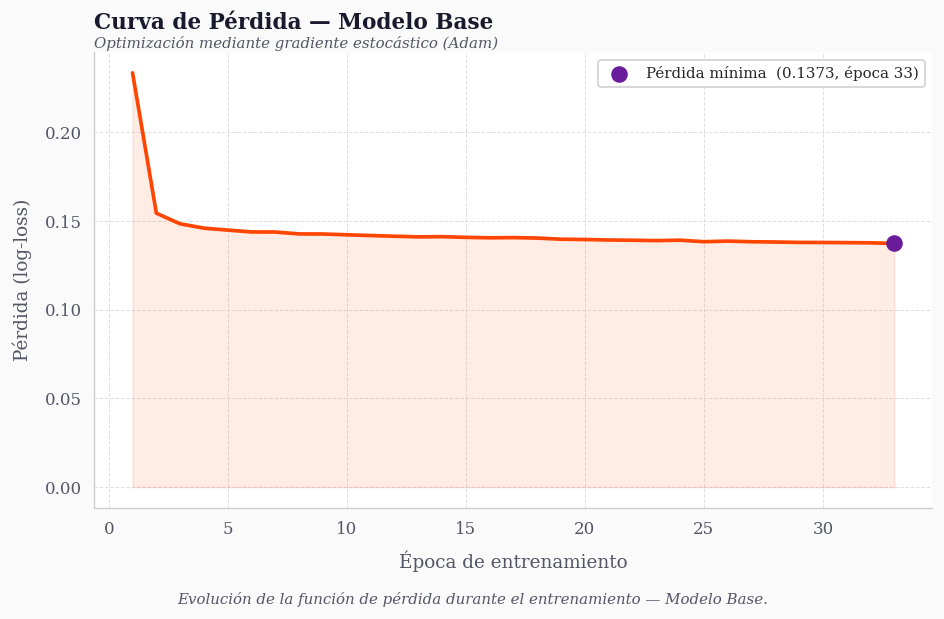

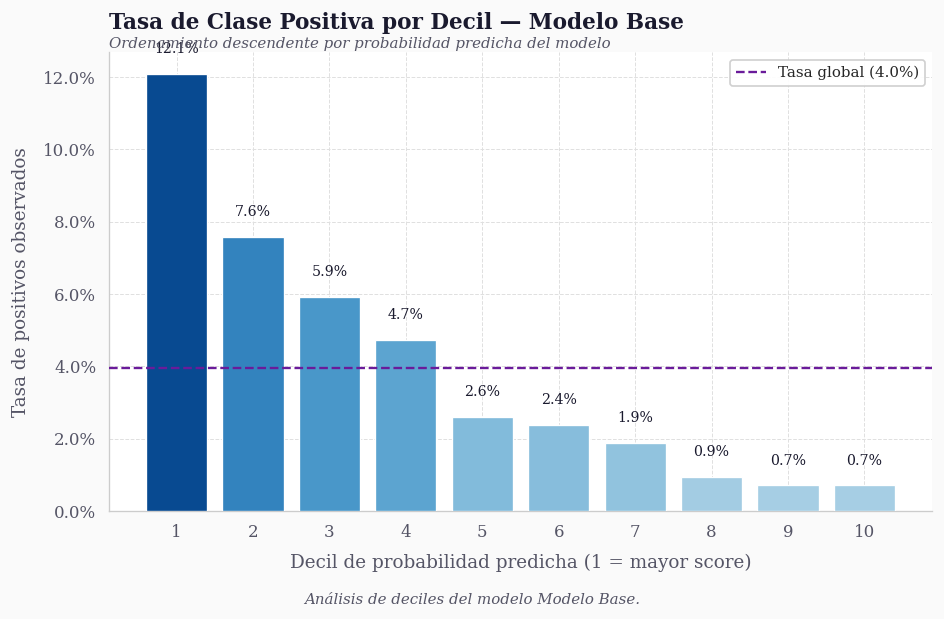


Evaluación del Modelo Base (umbral óptimo para recall: 0.20):
EvalResult(nombre='Base_umbral_optimo_recall', umbral=0.2, accuracy=0.9525954017539702, precision=0.22950819672131148, recall=0.08383233532934131, auc_roc=np.float64(0.748834020015251))


In [ ]:
print("\n--- Entrenando Modelo Base ---")
# Definir el modelo base (MLPClassifier)
base_model = MLPClassifier(
    random_state=RANDOM_STATE,
    max_iter=220,
    hidden_layer_sizes=(64, 32),
    learning_rate_init=0.001,
    alpha=0.0001,
    early_stopping=True,
    n_iter_no_change=12,
)

# Construir y entrenar el pipeline del modelo base
base_pipe = build_pipeline(num_all, cat_all, base_model)
base_pipe.fit(X_train[feat_all], y_train)
print("Modelo Base entrenado.")

# Predecir probabilidades en el conjunto de prueba
prob_base = base_pipe.predict_proba(X_test[feat_all])[:, 1]

# Evaluar el modelo base con un umbral de 0.5
eval_base_05 = evaluate_at_threshold(y_test, prob_base, 0.5, "Base_umbral_0.5")
print(f"\nEvaluación del Modelo Base (umbral=0.5):\n{eval_base_05}")

# Mostrar curvas ROC, Precision-Recall, Loss y Deciles para el modelo base
display_curve_plots(y_test, prob_base, "Modelo Base")
display_loss_plot(base_pipe.named_steps["model"], "Modelo Base")
display_deciles_plot(y_test.values, prob_base, "Modelo Base")

# Ajuste de umbral para optimizar 'recall' en el modelo base
th_table_base, best_th_base = threshold_search(y_test, prob_base, metric="recall")
eval_base_best = evaluate_at_threshold(y_test, prob_base, best_th_base, "Base_umbral_optimo_recall")
print(f"\nEvaluación del Modelo Base (umbral óptimo para recall: {best_th_base:.2f}):\n{eval_base_best}")

### 7. Tuning de Hiperparámetros y Selección de Características

Se realiza una búsqueda de hiperparámetros para encontrar la mejor configuración del MLPClassifier. Luego, se seleccionan las características numéricas más importantes utilizando Información Mutua y se combinan con características categóricas de negocio para entrenar un modelo mejorado.

In [ ]:
print("\n--- Tuning de Hiperparámetros ---")
# Realizar tuning de hiperparámetros del MLPClassifier
best_cfg, best_auc_val = tune_mlp(X_train[feat_all], y_train, num_all, cat_all)
print(f"Mejor configuración de hiperparámetros encontrada: {best_cfg}")
print(f"AUC en validación con la mejor configuración: {best_auc_val:.4f}")

print("\n--- Selección de Características ---")
# Seleccionar las top 5 características numéricas por Información Mutua
top_num_features = top_numeric_features_by_mi(df, TARGET, top_k=5)
print(f"Top 5 características numéricas por Información Mutua: {top_num_features}")

# Combinar con características categóricas de negocio
selected_features = top_num_features + ["Perfil", "Estado", "Genero"]
selected_num = [c for c in selected_features if c in num_all]
selected_cat = [c for c in selected_features if c in cat_all]

print(f"Características numéricas seleccionadas para el modelo mejorado: {selected_num}")
print(f"Características categóricas seleccionadas para el modelo mejorado: {selected_cat}")


--- Tuning de Hiperparámetros ---
Iniciando tuning de hiperparámetros...
  Probando configuración 1/12: {'alpha': 0.0001, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.001}
  Probando configuración 2/12: {'alpha': 0.0001, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.003}
  Probando configuración 3/12: {'alpha': 0.0001, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}
  Probando configuración 4/12: {'alpha': 0.0001, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.003}
  Probando configuración 5/12: {'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}
  Probando configuración 6/12: {'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.003}
  Probando configuración 7/12: {'alpha': 0.001, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.001}
  Probando configuración 8/12: {'alpha': 0.001, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.003}
  Probando configuración 9/12: {'alpha': 0.001, 'hidden_layer_size

### 8. Modelo con Características Seleccionadas: Entrenamiento y Evaluación

Se entrena un nuevo modelo con las características seleccionadas y los hiperparámetros optimizados. Se evalúa su rendimiento y se comparan los resultados con el modelo base.


--- Entrenando Modelo con Características Seleccionadas y Hiperparámetros Tuned ---
Modelo con Características Seleccionadas entrenado.

Evaluación del Modelo Seleccionado (umbral=0.5):
EvalResult(nombre='Seleccion_variables_umbral_0.5', umbral=0.5, accuracy=0.9599431144821048, precision=0.0, recall=0.0, auc_roc=np.float64(0.7557042873778602))


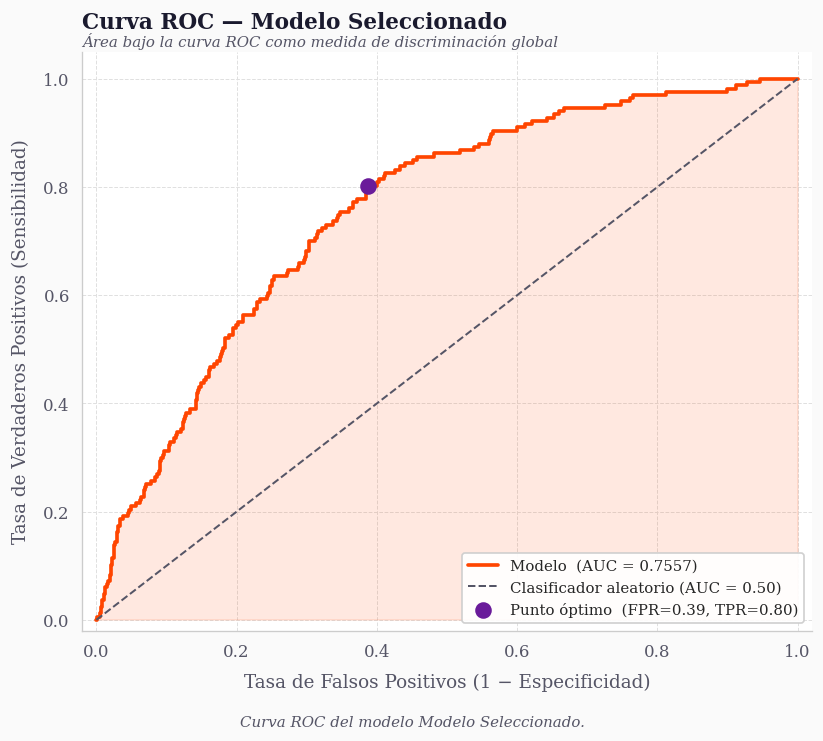

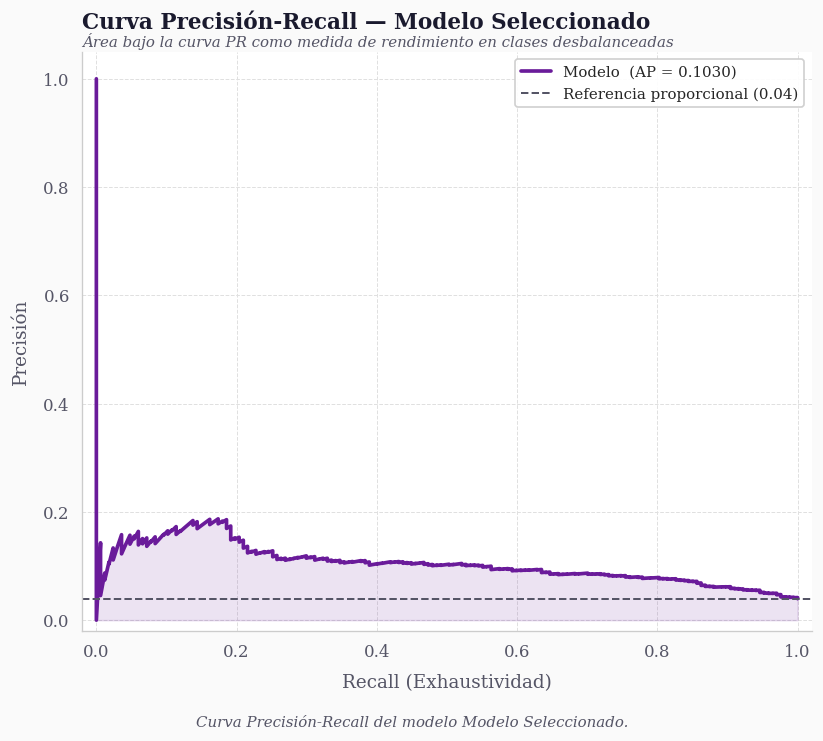

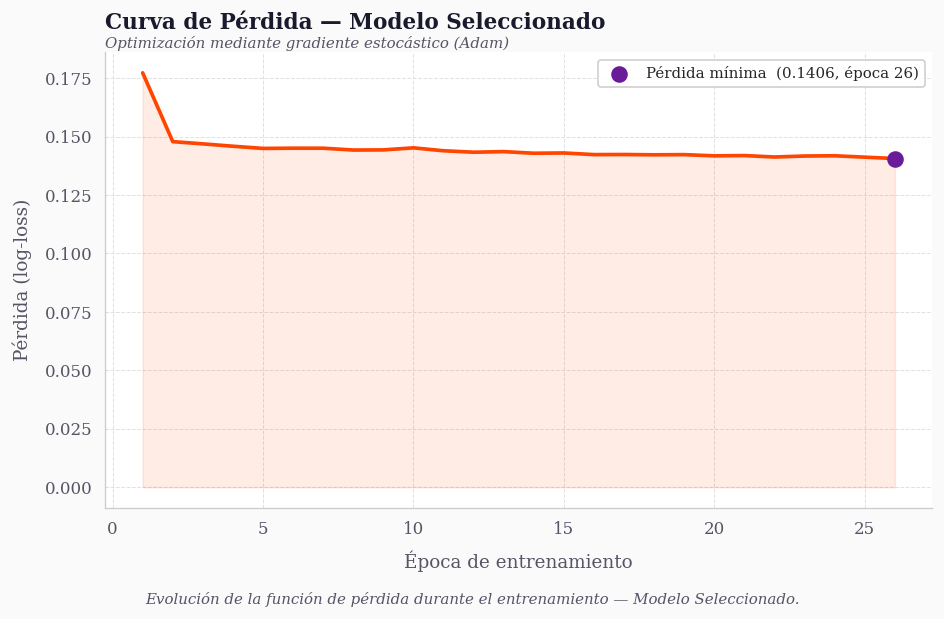

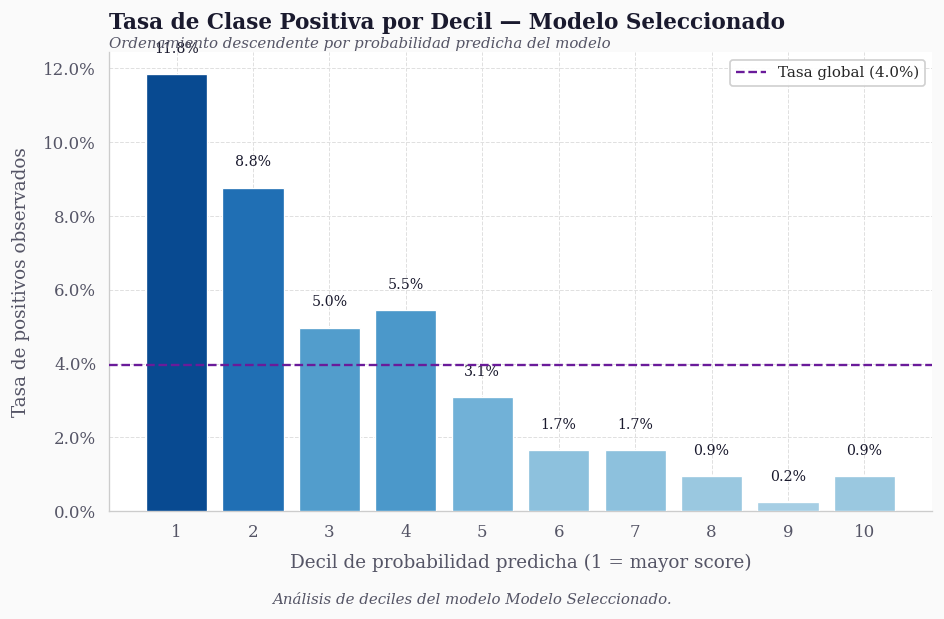


Evaluación del Modelo Seleccionado (umbral óptimo para recall: 0.20):
EvalResult(nombre='Seleccion_umbral_optimo_recall', umbral=0.2, accuracy=0.9502251718416687, precision=0.15873015873015872, recall=0.059880239520958084, auc_roc=np.float64(0.7557042873778602))


In [ ]:
print("\n--- Entrenando Modelo con Características Seleccionadas y Hiperparámetros Tuned ---")
# Configurar el modelo con los mejores hiperparámetros encontrados
sel_model = MLPClassifier(
    random_state=RANDOM_STATE,
    max_iter=260, # Un poco más de max_iter para el modelo final si es necesario
    early_stopping=True,
    n_iter_no_change=12,
    **best_cfg, # Usar los mejores hiperparámetros
)

# Construir y entrenar el pipeline con características seleccionadas
sel_pipe = build_pipeline(selected_num, selected_cat, sel_model)
sel_pipe.fit(X_train[selected_features], y_train)
print("Modelo con Características Seleccionadas entrenado.")

# Predecir probabilidades en el conjunto de prueba
prob_sel = sel_pipe.predict_proba(X_test[selected_features])[:, 1]

# Evaluar el modelo con un umbral de 0.5
eval_sel_05 = evaluate_at_threshold(y_test, prob_sel, 0.5, "Seleccion_variables_umbral_0.5")
print(f"\nEvaluación del Modelo Seleccionado (umbral=0.5):\n{eval_sel_05}")

# Mostrar curvas ROC, Precision-Recall, Loss y Deciles para el modelo seleccionado
display_curve_plots(y_test, prob_sel, "Modelo Seleccionado")
display_loss_plot(sel_pipe.named_steps["model"], "Modelo Seleccionado")
display_deciles_plot(y_test.values, prob_sel, "Modelo Seleccionado")

# Ajuste de umbral para optimizar 'recall' en el modelo seleccionado
th_table_sel, best_th_sel = threshold_search(y_test, prob_sel, metric="recall")
eval_sel_best = evaluate_at_threshold(y_test, prob_sel, best_th_sel, "Seleccion_umbral_optimo_recall")
print(f"\nEvaluación del Modelo Seleccionado (umbral óptimo para recall: {best_th_sel:.2f}):\n{eval_sel_best}")

### 9. Resumen de Resultados y Exportación

Se consolidan las métricas de evaluación de ambos modelos (base y seleccionado) y se exportan a archivos CSV. También se genera la matriz de confusión del modelo final (seleccionado con umbral optimizado) y un reporte de resumen en un archivo de texto.

In [ ]:
print("\n--- Resumen de Métricas ---")
# Consolidar resultados en un DataFrame
results = pd.DataFrame(
    [
        eval_base_05.__dict__,
        eval_base_best.__dict__,
        eval_sel_05.__dict__,
        eval_sel_best.__dict__,
    ]
)
display(results)

# Exportar resultados a CSV
results.to_csv(os.path.join(OUTPUT_DIR, "resumen_metricas.csv"), index=False)
th_table_base.to_csv(os.path.join(OUTPUT_DIR, "umbral_base.csv"), index=False)
th_table_sel.to_csv(os.path.join(OUTPUT_DIR, "umbral_seleccion.csv"), index=False)
print(f"Resultados de métricas y umbrales guardados en '{OUTPUT_DIR}'.")

print("\n--- Matriz de Confusión del Modelo Final ---")
# Matriz de confusión del modelo final (seleccionado + umbral optimizado).
y_pred_final = (prob_sel >= best_th_sel).astype(int)
cm = confusion_matrix(y_test, y_pred_final)
cm_df = pd.DataFrame(cm, index=["Real_0", "Real_1"], columns=["Pred_0", "Pred_1"])
display(cm_df)
cm_df.to_csv(os.path.join(OUTPUT_DIR, "matriz_confusion_modelo_final.csv"))
print(f"Matriz de confusión guardada en '{OUTPUT_DIR}'.")

# Generar reporte de resumen en archivo de texto
report_lines = [
    "=== REPORTE DE EJECUCION DE CLASIFICACION RNA ===",
    f"Fecha de Ejecución: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}",
    "",
    "### 1. Datos Generales ###",
    f"Archivo de entrada: {CSV_PATH}",
    f"Variable objetivo: {TARGET}",
    f"Registros totales: {len(df)}",
    f"Distribución de clases (0, 1): {distribucion_clases.to_dict()}",
    f"Semilla aleatoria (RANDOM_STATE): {RANDOM_STATE}",
    "",
    "### 2. Tuning de Hiperparámetros ###",
    f"Mejor configuración de hiperparámetros: {best_cfg}",
    f"AUC en validación (tuning): {best_auc_val:.4f}",
    "",
    "### 3. Selección de Características ###",
    f"Variables numéricas seleccionadas por Información Mutua: {top_num_features}",
    f"Variables categóricas de negocio utilizadas: {["Perfil", "Estado", "Genero"]}",
    f"Todas las características usadas en el modelo seleccionado: {selected_features}",
    "",
    "### 4. Métricas de Evaluación Final ###",
    results.to_string(index=False),
    "",
    "### 5. Umbrales Óptimos ###",
    f"Umbral óptimo Modelo Base (recall): {best_th_base:.2f}",
    f"Umbral óptimo Modelo Seleccionado (recall): {best_th_sel:.2f}",
    "",
    "### 6. Matriz de Confusión del Modelo Final (Seleccionado con Umbral Óptimo) ###",
    cm_df.to_string(),
    "",
    "=== FIN DEL REPORTE ===",
]

with open(os.path.join(OUTPUT_DIR, "reporte_resumen.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print(f"Reporte de resumen generado en '{os.path.join(OUTPUT_DIR, 'reporte_resumen.txt')}'.")
print("\nProceso de clasificación completado exitosamente.")


--- Resumen de Métricas ---


,nombre,umbral,accuracy,precision,recall,auc_roc
0,Base_umbral_0.5,0.5,0.959706,0.000000,0.000000,0.748834
1,Base_umbral_optimo_recall,0.2,0.952595,0.229508,0.083832,0.748834
2,Seleccion_variables_umbral_0.5,0.5,0.959943,0.000000,0.000000,0.755704
3,Seleccion_umbral_optimo_recall,0.2,0.950225,0.158730,0.059880,0.755704


Resultados de métricas y umbrales guardados en 'outputs_rna'.

--- Matriz de Confusión del Modelo Final ---


,Pred_0,Pred_1
Real_0,3999,53
Real_1,157,10


Matriz de confusión guardada en 'outputs_rna'.
Reporte de resumen generado en 'outputs_rna/reporte_resumen.txt'.

Proceso de clasificación completado exitosamente.
